# Libraries

In [1]:
# Data Preparation
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
from transformers import AutoTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Device

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


# Data Preprocessing & Preparation

In [3]:
stop_words_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

from transformers import AutoTokenizer, AutoModel

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")
model = AutoModel.from_pretrained("microsoft/deberta-v3-small")

def embedding(sentences, max_len=64):
    """
    Tokenize and encode sentences into DeBERTa embeddings.
    """
    # Tokenize input sentences
    inputs = tokenizer(sentences, return_tensors='pt', padding=True, truncation=True, max_length=max_len)

    # Disable gradient calculation
    with torch.no_grad():
        outputs = model(**inputs)

    # Use first token <s> as [CLS] equivalent in RoBERTa
    return outputs.last_hidden_state[:, 0, :]


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/Users/macbookpro/anaconda3/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [4]:
from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# Preprocessing pipelien
transform_pipeline = preprocessing.Compose([
    preprocessing.Lowercase()
    #preprocessing.Tokenize(tokenizer),
    #preprocessing.StopwordsRemoval(stop_words_list),
    #preprocessing.POStagging(),
    #preprocessing.Lemmatization(lemmatizer), 
])

In [5]:
# 1. Load dataset and apply prior Transform 
train_dataset = IMDBDataset(base_path='aclImdb', size=2000, train=True, transform=transform_pipeline)
test_dataset = IMDBDataset(base_path='aclImdb', size=1000, train=False, transform=transform_pipeline)
print(train_dataset.df.head())

# 2. Extract preprocessed texts and labels
train_input = [train_dataset[i][0] for i in range(len(train_dataset))]
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

test_input = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

# 3. Apply BERT Embeddings to the whole dataset
train_embedded_features = embedding(train_input)
test_embedded_features = embedding(test_input)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# 5. Construct dataset for dataloader
train_dataset = torch.utils.data.TensorDataset(train_embedded_features, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(test_embedded_features, y_test_tensor)

      id                                             review  score sentiment
0   4747  Anyone who had never seen anything like the fi...      8  positive
1  11335  Jake's Closet has the emotional power of Krame...      9  positive
2  10604  Henry Thomas showed a restraint, even when the...      7  positive
3   9000  I first saw BLOOD OF THE SAMURAI at its premie...     10  positive
4  11766  This movie has everything you want from an act...      8  positive


/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_16045/3393106566.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_16045/3393106566.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)


# Split data for training and validation

In [6]:
# Split train_dataset into training and validation set
from sklearn.model_selection import train_test_split

#Split dataset for train and validation
train_size = int(0.8 * len(train_dataset))
train_indices, val_indices = train_test_split(list(range(len(train_dataset))),
                                              test_size=len(train_dataset) - train_size,
                                              stratify=y_train_tensor,
                                              random_state=42)

trainset = torch.utils.data.Subset(train_dataset, train_indices)
valset = torch.utils.data.Subset(train_dataset, val_indices)

#DataLoader to handle batching and shuffling
batch_size = 32
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Model

# Training + Evaluation

In [7]:
from train_test import train_model, test_model, plot_accuracy_loss, plot_confusion_matrix
import classifier as clf

# init paramètre
nb_epochs = 64
optimizer = 'Adam'
lr = 0.001

SimpleClassifier(
  (fc1): Linear(in_features=768, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


38552 total parameters.
38552 training parameters.




  6%|▋         | 4/64 [00:00<00:06,  9.75it/s]

| Epoch: [1/64] | Train: Loss 0.6959 Accuracy : 0.5006 | Val: Loss 0.7233 Accuracy : 0.5000

| Epoch: [2/64] | Train: Loss 0.6920 Accuracy : 0.5175 | Val: Loss 0.7161 Accuracy : 0.5000

| Epoch: [3/64] | Train: Loss 0.6884 Accuracy : 0.5294 | Val: Loss 0.7130 Accuracy : 0.5000

| Epoch: [4/64] | Train: Loss 0.6853 Accuracy : 0.5425 | Val: Loss 0.7120 Accuracy : 0.5000

| Epoch: [5/64] | Train: Loss 0.6821 Accuracy : 0.5544 | Val: Loss 0.7112 Accuracy : 0.5000

| Epoch: [6/64] | Train: Loss 0.6787 Accuracy : 0.5656 | Val: Loss 0.7104 Accuracy : 0.5000



 16%|█▌        | 10/64 [00:00<00:02, 19.03it/s]

| Epoch: [7/64] | Train: Loss 0.6749 Accuracy : 0.5825 | Val: Loss 0.7069 Accuracy : 0.5000

| Epoch: [8/64] | Train: Loss 0.6707 Accuracy : 0.5962 | Val: Loss 0.6981 Accuracy : 0.5000

| Epoch: [9/64] | Train: Loss 0.6667 Accuracy : 0.5988 | Val: Loss 0.6896 Accuracy : 0.5075

| Epoch: [10/64] | Train: Loss 0.6628 Accuracy : 0.6094 | Val: Loss 0.6821 Accuracy : 0.5200

| Epoch: [11/64] | Train: Loss 0.6590 Accuracy : 0.6031 | Val: Loss 0.6751 Accuracy : 0.5175

| Epoch: [12/64] | Train: Loss 0.6547 Accuracy : 0.6088 | Val: Loss 0.6681 Accuracy : 0.5225



...

| Epoch: [50/64] | Train: Loss 0.5490 Accuracy : 0.7231 | Val: Loss 0.5582 Accuracy : 0.7175

| Epoch: [51/64] | Train: Loss 0.5478 Accuracy : 0.7250 | Val: Loss 0.5576 Accuracy : 0.7150

| Epoch: [52/64] | Train: Loss 0.5466 Accuracy : 0.7244 | Val: Loss 0.5571 Accuracy : 0.7150

| Epoch: [53/64] | Train: Loss 0.5452 Accuracy : 0.7306 | Val: Loss 0.5564 Accuracy : 0.7150

| Epoch: [54/64] | Train: Loss 0.5442 Accuracy : 0.7300 | Val: Loss 0.5558 Accuracy : 0.7150

| Epoch: [55/64] | Train: Loss 0.5430 Accuracy : 0.7294 | Val: Loss 0.5552 Accuracy : 0.7175

| Epoch: [56/64] | Train: Loss 0.5419 Accuracy : 0.7300 | Val: Loss 0.5547 Accuracy : 0.7200



 94%|█████████▍| 60/64 [00:02<00:00, 26.22it/s]

| Epoch: [57/64] | Train: Loss 0.5408 Accuracy : 0.7338 | Val: Loss 0.5542 Accuracy : 0.7200

| Epoch: [58/64] | Train: Loss 0.5398 Accuracy : 0.7338 | Val: Loss 0.5538 Accuracy : 0.7225

| Epoch: [59/64] | Train: Loss 0.5387 Accuracy : 0.7338 | Val: Loss 0.5532 Accuracy : 0.7200

| Epoch: [60/64] | Train: Loss 0.5377 Accuracy : 0.7350 | Val: Loss 0.5528 Accuracy : 0.7200

| Epoch: [61/64] | Train: Loss 0.5370 Accuracy : 0.7356 | Val: Loss 0.5523 Accuracy : 0.7200

| Epoch: [62/64] | Train: Loss 0.5358 Accuracy : 0.7344 | Val: Loss 0.5520 Accuracy : 0.7200



100%|██████████| 64/64 [00:02<00:00, 22.68it/s]


| Epoch: [63/64] | Train: Loss 0.5350 Accuracy : 0.7356 | Val: Loss 0.5517 Accuracy : 0.7200

| Epoch: [64/64] | Train: Loss 0.5341 Accuracy : 0.7350 | Val: Loss 0.5514 Accuracy : 0.7200


Test accuracy: 0.708


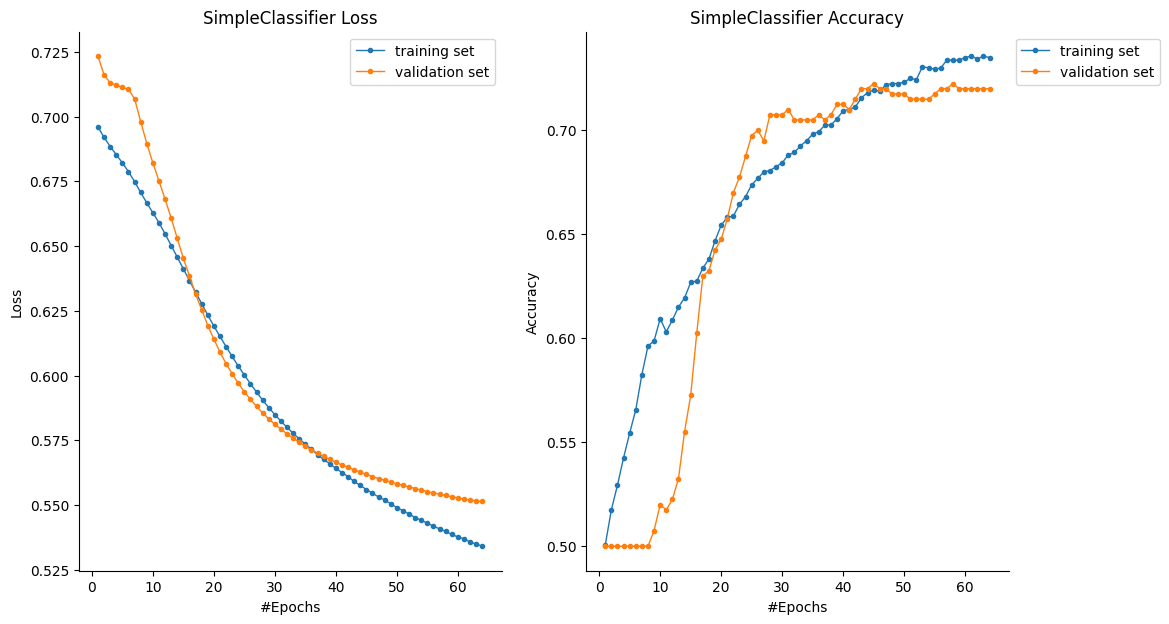

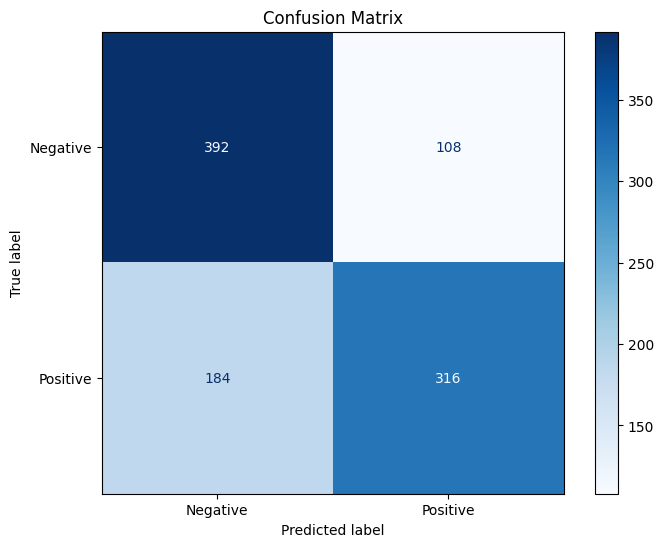

In [8]:
input_dim = train_dataset.tensors[0].shape[1]
model = clf.SimpleClassifier(input_dim=input_dim).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("SimpleClassifier", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# LSTM

LSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


592130 total parameters.
592130 training parameters.




  3%|▎         | 2/64 [00:00<00:11,  5.40it/s]

| Epoch: [1/64] | Train: Loss 0.6950 Accuracy : 0.4913 | Val: Loss 0.6930 Accuracy : 0.5000

| Epoch: [2/64] | Train: Loss 0.6932 Accuracy : 0.5106 | Val: Loss 0.6931 Accuracy : 0.5000



  6%|▋         | 4/64 [00:00<00:09,  6.36it/s]

| Epoch: [3/64] | Train: Loss 0.6919 Accuracy : 0.5250 | Val: Loss 0.6930 Accuracy : 0.5000

| Epoch: [4/64] | Train: Loss 0.6908 Accuracy : 0.5331 | Val: Loss 0.6928 Accuracy : 0.5000



...

| Epoch: [59/64] | Train: Loss 0.4939 Accuracy : 0.7569 | Val: Loss 0.5793 Accuracy : 0.6950

| Epoch: [60/64] | Train: Loss 0.4931 Accuracy : 0.7550 | Val: Loss 0.5860 Accuracy : 0.6875



 97%|█████████▋| 62/64 [00:08<00:00,  7.26it/s]

| Epoch: [61/64] | Train: Loss 0.4913 Accuracy : 0.7544 | Val: Loss 0.5895 Accuracy : 0.6850

| Epoch: [62/64] | Train: Loss 0.4891 Accuracy : 0.7544 | Val: Loss 0.5914 Accuracy : 0.6825



100%|██████████| 64/64 [00:08<00:00,  7.35it/s]

| Epoch: [63/64] | Train: Loss 0.4869 Accuracy : 0.7544 | Val: Loss 0.5956 Accuracy : 0.6800

| Epoch: [64/64] | Train: Loss 0.4844 Accuracy : 0.7569 | Val: Loss 0.5951 Accuracy : 0.6800


Test accuracy: 0.675


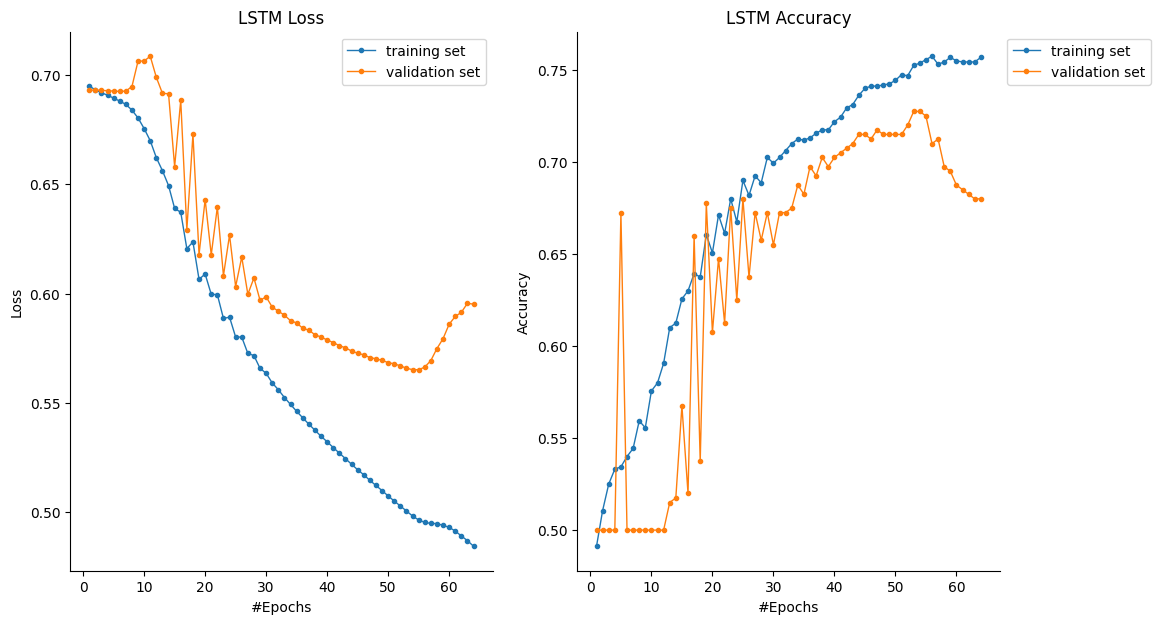

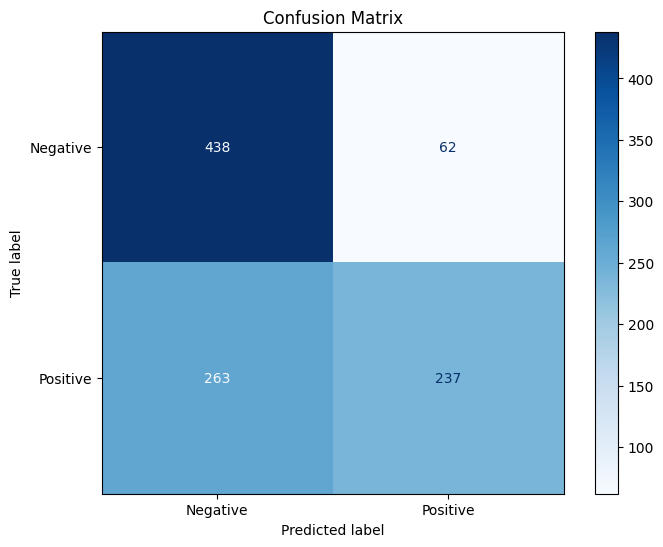

In [9]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMClassifier(input_dim=input_dim, hidden_dim=128, num_layers=2, output_dim=2, bidirectional=False).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Deeper LSTM

DeepLSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1726658 total parameters.
1726658 training parameters.




  2%|▏         | 1/64 [00:00<00:20,  3.05it/s]

| Epoch: [1/64] | Train: Loss 0.6936 Accuracy : 0.5012 | Val: Loss 0.6932 Accuracy : 0.5000



  3%|▎         | 2/64 [00:00<00:20,  3.04it/s]

| Epoch: [2/64] | Train: Loss 0.6828 Accuracy : 0.5675 | Val: Loss 0.7269 Accuracy : 0.5000



...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.0392 Accuracy : 0.5000



 98%|█████████▊| 63/64 [00:19<00:00,  3.14it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.0451 Accuracy : 0.5000



100%|██████████| 64/64 [00:20<00:00,  3.16it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.0457 Accuracy : 0.5000


Test accuracy: 0.5


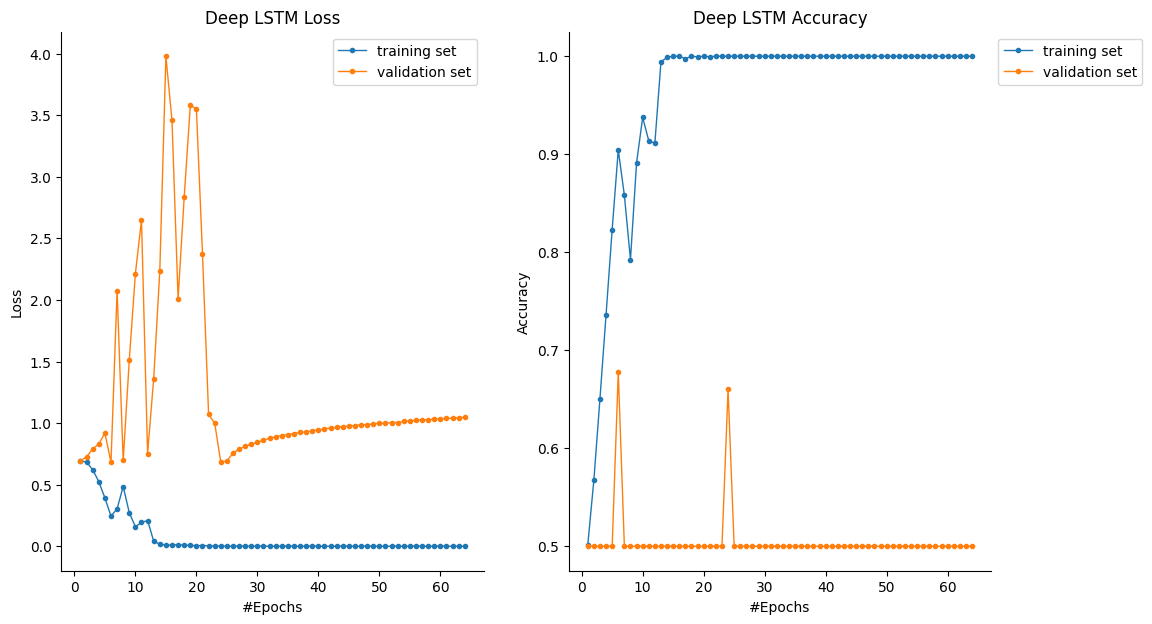

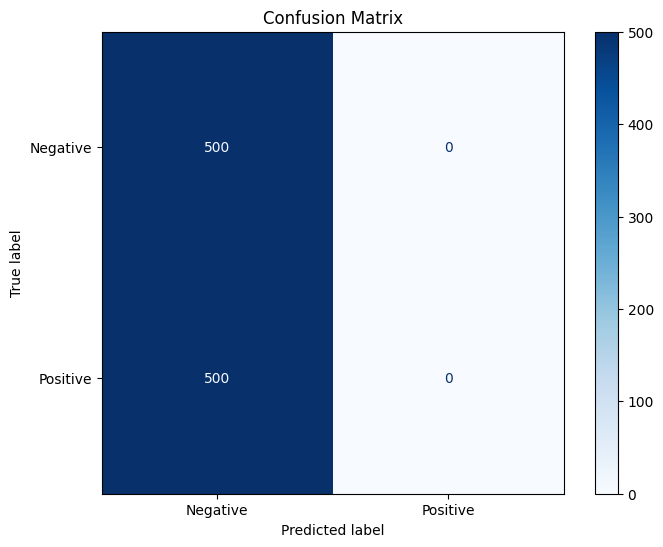

In [10]:
input_dim = X_train_tensor.shape[1]  
model = clf.DeepLSTMClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=3,
    fc_hidden_dim=64,
    output_dim=2,  # set this to the number of classes
    dropout=0.4,
    bidirectional=True
).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Deep LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Attention LSTM

LSTMWithAttentionClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1331651 total parameters.
1331651 training parameters.




  2%|▏         | 1/64 [00:00<00:16,  3.86it/s]

| Epoch: [1/64] | Train: Loss 0.6954 Accuracy : 0.4894 | Val: Loss 0.6933 Accuracy : 0.5000



  3%|▎         | 2/64 [00:00<00:15,  3.92it/s]

| Epoch: [2/64] | Train: Loss 0.6913 Accuracy : 0.5231 | Val: Loss 0.6938 Accuracy : 0.5000



...

| Epoch: [62/64] | Train: Loss 0.0029 Accuracy : 1.0000 | Val: Loss 0.9069 Accuracy : 0.5000



 98%|█████████▊| 63/64 [00:15<00:00,  3.98it/s]

| Epoch: [63/64] | Train: Loss 0.0028 Accuracy : 1.0000 | Val: Loss 0.8620 Accuracy : 0.5000



100%|██████████| 64/64 [00:16<00:00,  3.95it/s]

| Epoch: [64/64] | Train: Loss 0.0025 Accuracy : 1.0000 | Val: Loss 0.8329 Accuracy : 0.5000


Test accuracy: 0.5


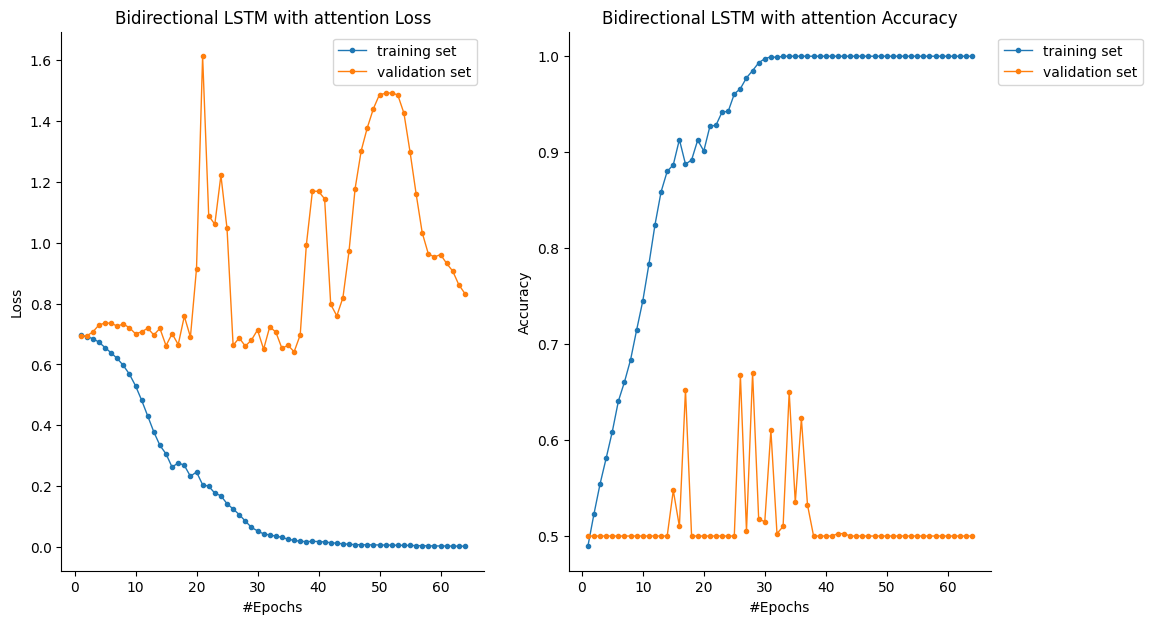

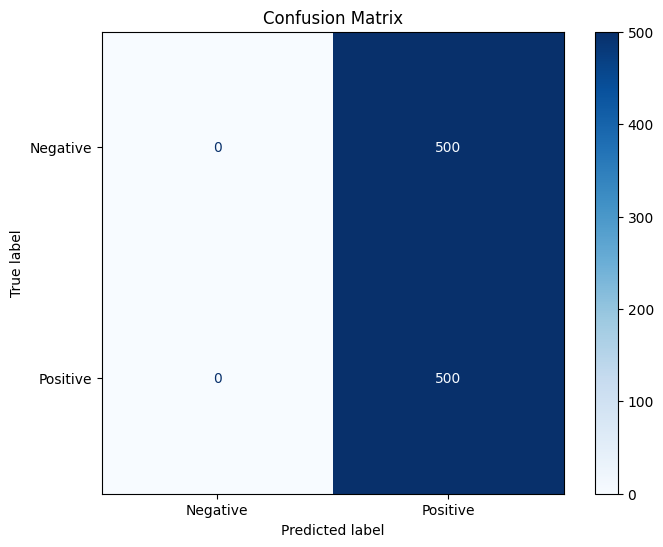

In [11]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMWithAttentionClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=2,
    output_dim=2,
    dropout=0.3,
    fc_hidden_dim=64,
    bidirectional=True
).to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Bidirectional LSTM with attention", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])